In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
#load in and explore the data 
df= pd.read_csv('C:\\Users\\HP\\Downloads\\Ew2qx0UzQiGM1quAeD6d_Instagram visits clustering - hart demerchant - Instagram visits clustering - hart demerchant (1).csv')

In [6]:
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User ID                  2600 non-null   int64  
 1   Instagram visit score    2600 non-null   int64  
 2   Spending_rank(0 to 100)  2600 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 61.1 KB


In [8]:
df.describe()

,User ID,Instagram visit score,Spending_rank(0 to 100)
count,2600.000000,2600.000000,2600.000000
mean,1299.500000,63.323462,42.848408
std,750.699674,26.579760,28.758349
min,0.000000,5.000000,0.940709
25%,649.750000,38.000000,19.452098
50%,1299.500000,72.000000,28.013082
75%,1949.250000,86.000000,72.116945
max,2599.000000,118.000000,107.349821


In [9]:
#data preparation
df.isnull().sum()

User ID                    0
Instagram visit score      0
Spending_rank(0 to 100)    0
dtype: int64

In [10]:
clustering_features = df[['Instagram visit score', 'Spending_rank(0 to 100)']]
clustering_features.head()

,Instagram visit score,Spending_rank(0 to 100)
0,63,24.050708
1,61,25.223290
2,104,18.528245
3,82,86.890232
4,14,31.492397


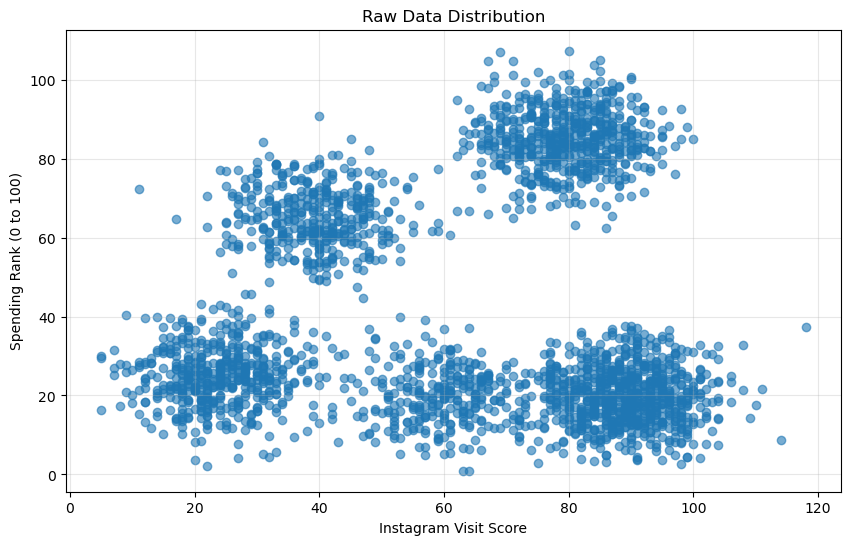

In [11]:
# Visualize the raw data
plt.figure(figsize=(10, 6))
plt.scatter(clustering_features['Instagram visit score'], clustering_features['Spending_rank(0 to 100)'], alpha=0.6)
plt.xlabel('Instagram Visit Score')
plt.ylabel('Spending Rank (0 to 100)')
plt.title('Raw Data Distribution')
plt.grid(True, alpha=0.3) # alpha=0.3 makes the grid lines faint (semi-transparent).
plt.show()

In [12]:
# Test different numbers of clusters
k_range = range(2, 11)
empty_inertias = []

for k in k_range:
    # Create KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Fit the model
    kmeans.fit(clustering_features)

    # Store the inertia (within-cluster sum of squares)
    empty_inertias.append(kmeans.inertia_)

    print(f"k={k}: Inertia = {kmeans.inertia_:.2f}")

k=2: Inertia = 2079619.33
k=3: Inertia = 847024.58
k=4: Inertia = 440248.79
k=5: Inertia = 278407.52
k=6: Inertia = 251438.17
k=7: Inertia = 228195.72
k=8: Inertia = 208398.07
k=9: Inertia = 189725.80
k=10: Inertia = 174565.76


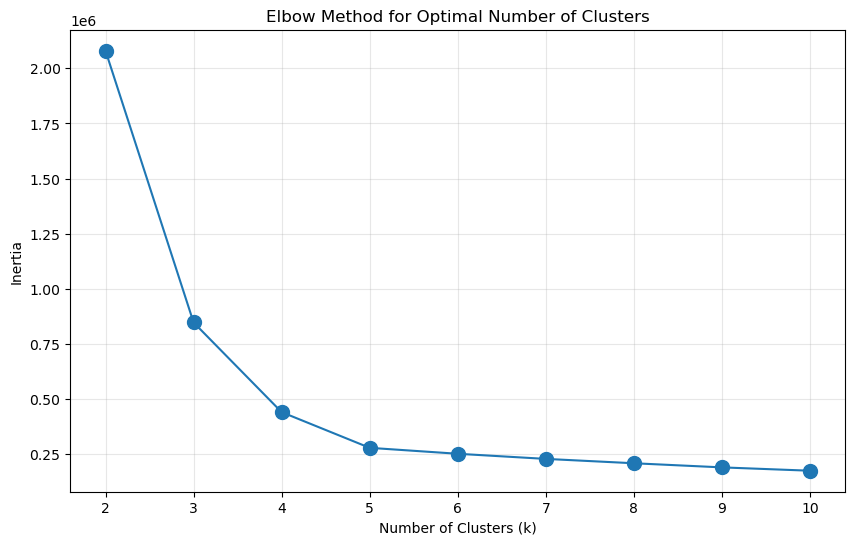

In [13]:
# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, empty_inertias, 'o-', markersize=10)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
silhouette_scores = []

for k in k_range:
    # Create and fit KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(clustering_features)

    # Calculate silhouette score
    silhouette_avg = silhouette_score(clustering_features, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    print(f"k={k}: Silhouette Score = {silhouette_avg:.3f}")

k=2: Silhouette Score = 0.490
k=3: Silhouette Score = 0.595
k=4: Silhouette Score = 0.647
k=5: Silhouette Score = 0.620
k=6: Silhouette Score = 0.539
k=7: Silhouette Score = 0.448
k=8: Silhouette Score = 0.446
k=9: Silhouette Score = 0.384
k=10: Silhouette Score = 0.339


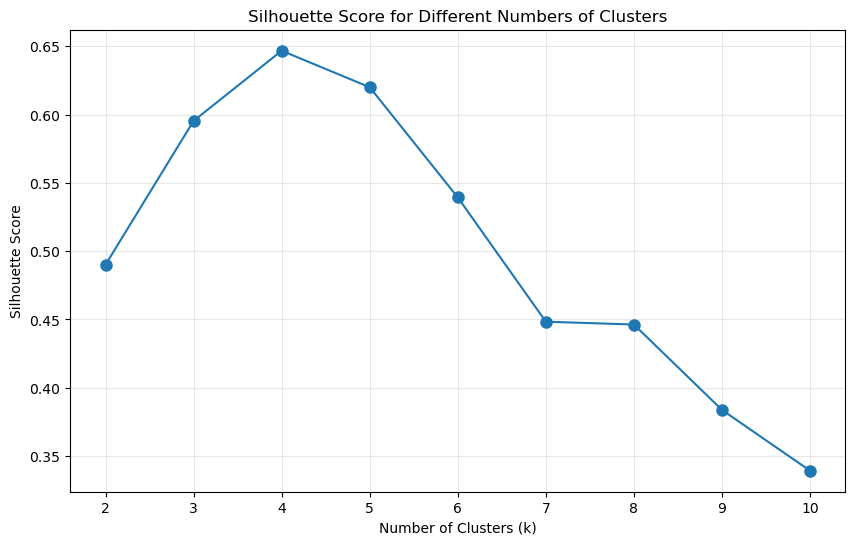

In [15]:
# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'o-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Numbers of Clusters')
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# Create the final model
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fit the model and get cluster labels
cluster_labels = final_kmeans.fit_predict(clustering_features)

In [17]:
cluster_labels[:10]

array([0, 0, 0, 2, 3, 2, 2, 2, 1, 0])

In [18]:
# Add cluster labels to original dataframe
df_clustered = df.copy()
df_clustered['predicted_cluster'] = cluster_labels

In [19]:
df_clustered["predicted_cluster"].unique()

array([0, 2, 3, 1])

In [20]:
df_clustered.head()

,User ID,Instagram visit score,Spending_rank(0 to 100),predicted_cluster
0,0,63,24.050708,0
1,1,61,25.223290,0
2,2,104,18.528245,0
3,3,82,86.890232,2
4,4,14,31.492397,3


In [21]:
# Cluster distribution
cluster_counts = pd.Series(cluster_labels).value_counts()
print(cluster_counts)

0    1027
2     600
3     573
1     400
Name: count, dtype: int64


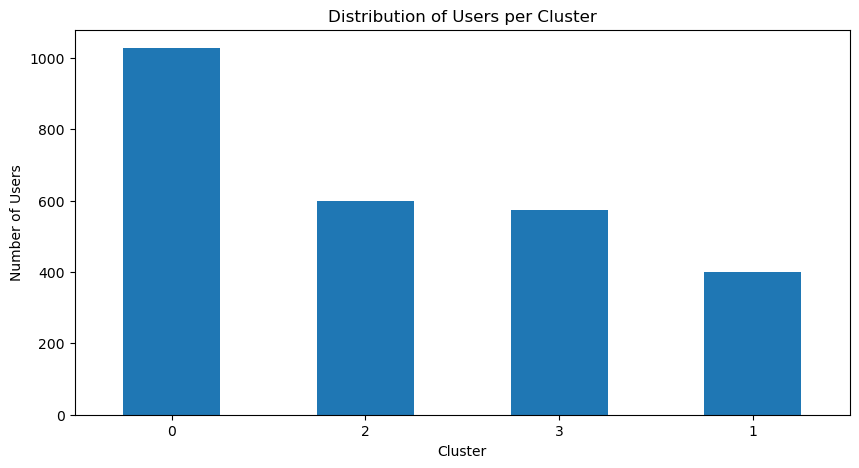

In [22]:
plt.figure(figsize=(10, 5))
cluster_counts.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.title('Distribution of Users per Cluster')
plt.xticks(rotation=0)
plt.show()

In [23]:
cluster_characteristics = df_clustered.groupby('predicted_cluster')[['Instagram visit score', 'Spending_rank(0 to 100)']].mean()
display(cluster_characteristics)

,Instagram visit score,Spending_rank(0 to 100)
predicted_cluster,,
0,83.243427,19.872486
1,39.350000,65.132485
2,79.615000,85.024498
3,27.296684,24.309119


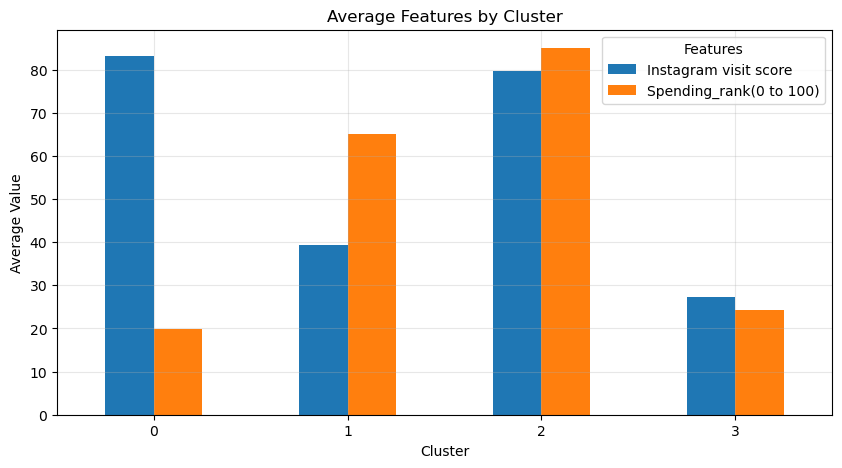

In [24]:
# Plot 4: Feature comparison by cluster
fig, axes = plt.subplots(figsize=(10, 5))
cluster_characteristics.plot(kind='bar', ax=axes)
axes.set_xlabel('Cluster')
axes.set_ylabel('Average Value')
axes.set_title('Average Features by Cluster')
axes.tick_params(axis='x', rotation=0)
axes.legend(title='Features')
axes.grid(True, alpha=0.3)
plt.show()